# Minería de Datos – Clase Completa (2 Horas)
## Entrenamiento, Testing y Métricas de Evaluación

Notebook diseñado para clase universitaria con teoría, ejemplos, ejercicios y práctica guiada.

## Agenda de Clase
1. ¿Qué significa entrenar un modelo?
2. Generalización y problema de sobreajuste
3. Train / Validation / Test Split
4. Data Leakage
5. Matriz de Confusión
6. Métricas de Clasificación
7. Caso práctico completo
8. Discusión y preguntas de cierre

## 1. ¿Qué significa entrenar un modelo?
Un modelo de ML aprende patrones a partir de datos históricos para generalizar sobre datos no vistos.

## 2. Overfitting vs Underfitting
- **Overfitting:** memoriza el entrenamiento, falla en nuevos datos.
- **Underfitting:** modelo demasiado simple.

### Analogía
Memorizar respuestas del parcial vs entender la materia.

## 3. División de Datos
- Train: aprendizaje
- Validation: ajuste de hiperparámetros
- Test: evaluación final

In [2]:
%pip install scikit-learn pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (398, 30)
Validation: (85, 30)
Test: (86, 30)


## 4. Data Leakage
Ocurre cuando información del test influye en el entrenamiento.

### Ejemplos comunes
- Escalar antes de dividir
- Imputar usando todo el dataset
- Variables derivadas del target

## 5. Primer Modelo Base
Usaremos Regresión Logística como baseline de clasificación.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=500))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## 6. Predicción y Matriz de Confusión

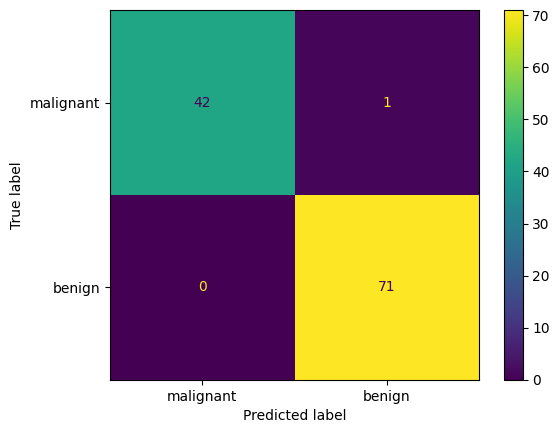

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.show()

## 7. Métricas de Evaluación

### Accuracy
\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

### Precision
\[
Precision = \frac{TP}{TP + FP}
\]

### Recall
\[
Recall = \frac{TP}{TP + FN}
\]

### F1-Score
\[
F1 = 2\frac{Precision \cdot Recall}{Precision + Recall}
\]


In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       1.00      0.97      0.98        32
      benign       0.98      1.00      0.99        54

    accuracy                           0.99        86
   macro avg       0.99      0.98      0.99        86
weighted avg       0.99      0.99      0.99        86



## 8. Discusión de Negocio
- En medicina suele importar más Recall.
- En detección de spam puede importar más Precision.
- Accuracy sola puede ser engañosa.

## 9. Ejercicio Guiado para Estudiantes
1. ¿Qué pasa si entrenamos y evaluamos sobre train?
2. Cambie test_size a 0.40 y compare métricas.
3. Investigue qué métrica usaría en fraude bancario y por qué.

In [11]:
y_train_pred = pipeline.predict(X_train)
print(classification_report(y_train, y_train_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.99      0.97      0.98       127
      benign       0.98      1.00      0.99       214

    accuracy                           0.99       341
   macro avg       0.99      0.98      0.98       341
weighted avg       0.99      0.99      0.99       341



## 10. Cierre de Clase
Con esto los estudiantes quedan preparados para la siguiente sesión:
**Regresión Logística en profundidad / Árboles de Decisión**